In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [73]:
df = pd.read_csv('Iris.csv')

In [74]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [75]:
df = df.iloc[:,1:]

In [76]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [77]:
from sklearn.preprocessing import LabelEncoder

In [78]:
encoder = LabelEncoder()

In [79]:
df['Species'] = encoder.fit_transform(df['Species'])

In [80]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [81]:
df = df[df['Species'] != 0][['SepalLengthCm', 'PetalLengthCm', 'Species']]

In [82]:
df.head()

,SepalLengthCm,PetalLengthCm,Species
50,7.0,4.7,1
51,6.4,4.5,1
52,6.9,4.9,1
53,5.5,4.0,1
54,6.5,4.6,1


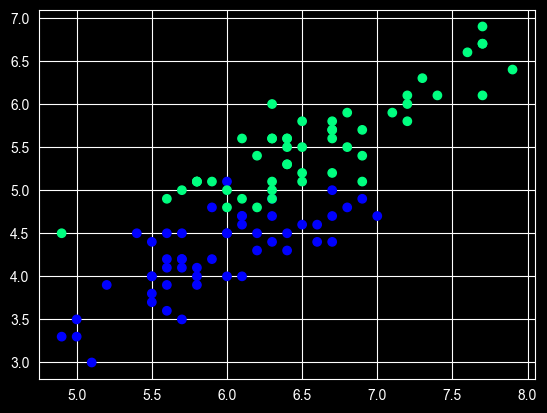

In [83]:
plt.scatter(df['SepalLengthCm'], df['PetalLengthCm'], c=df['Species'], cmap='winter')
plt.show()

In [84]:
# Taking only 10 rows for training

df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [85]:
df_train

,SepalLengthCm,PetalLengthCm,Species
105,7.6,6.6,2
110,6.5,5.1,2
133,6.3,5.1,2
141,6.9,5.1,2
66,5.6,4.5,1
107,7.3,6.3,2
89,5.5,4.0,1
64,5.6,3.6,1
144,6.7,5.7,2
134,6.1,5.6,2


In [86]:
df_test

,SepalLengthCm,PetalLengthCm,Species
109,7.2,6.1,2
102,7.1,5.9,2
100,6.3,6.0,2
72,6.3,4.9,1
79,5.7,3.5,1


In [87]:
df_val

,SepalLengthCm,PetalLengthCm,Species
77,6.7,5.0,1
88,5.6,4.1,1
70,5.9,4.8,1
65,6.7,4.4,1
50,7.0,4.7,1


In [88]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [89]:
X_test, y_test

(array([[6.7, 5. ],
        [5.6, 4.1],
        [5.9, 4.8],
        [6.7, 4.4],
        [7. , 4.7]]),
 array([1, 1, 1, 1, 1]))

# Case 1 - Bagging

In [90]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2].values
y = df_bag.iloc[:,-1].values

df_bag

,SepalLengthCm,PetalLengthCm,Species
105,7.6,6.6,2
66,5.6,4.5,1
141,6.9,5.1,2
105,7.6,6.6,2
133,6.3,5.1,2
89,5.5,4.0,1
134,6.1,5.6,2
66,5.6,4.5,1


In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [92]:
df1_bag1 = DecisionTreeClassifier()

In [93]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf=clf,legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

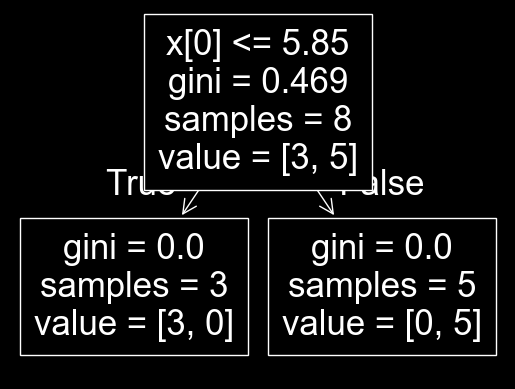

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [94]:
evaluate(df1_bag1,X,y)

In [95]:
# same for the second part

In [ ]:
# prediction